In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

sns.set_theme(style="whitegrid")

cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


In [2]:
print("Dataset Info:")
print(f"Total Samples  : {df.shape[0]}")
print(f"Total Features : {df.shape[1]-2}")
print(f"Malignant (0)  : {(df.target==0).sum()}")
print(f"Benign    (1)  : {(df.target==1).sum()}")
print(f"\nMissing Values : {df.isnull().sum().sum()}")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
df.describe()

Dataset Info:
Total Samples  : 569
Total Features : 30
Malignant (0)  : 212
Benign    (1)  : 357

Missing Values : 0

Data Types:
float64    30
int64       1
str         1
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


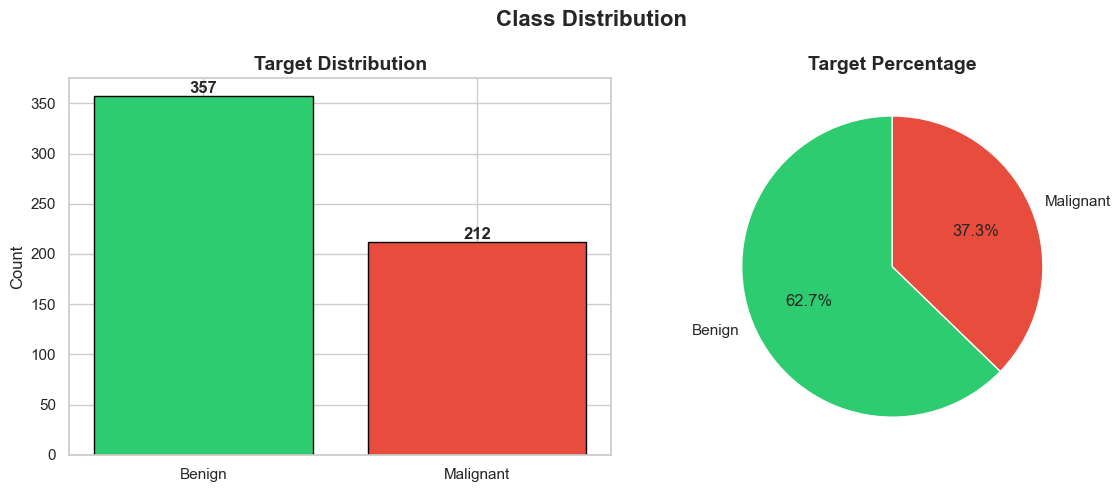

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

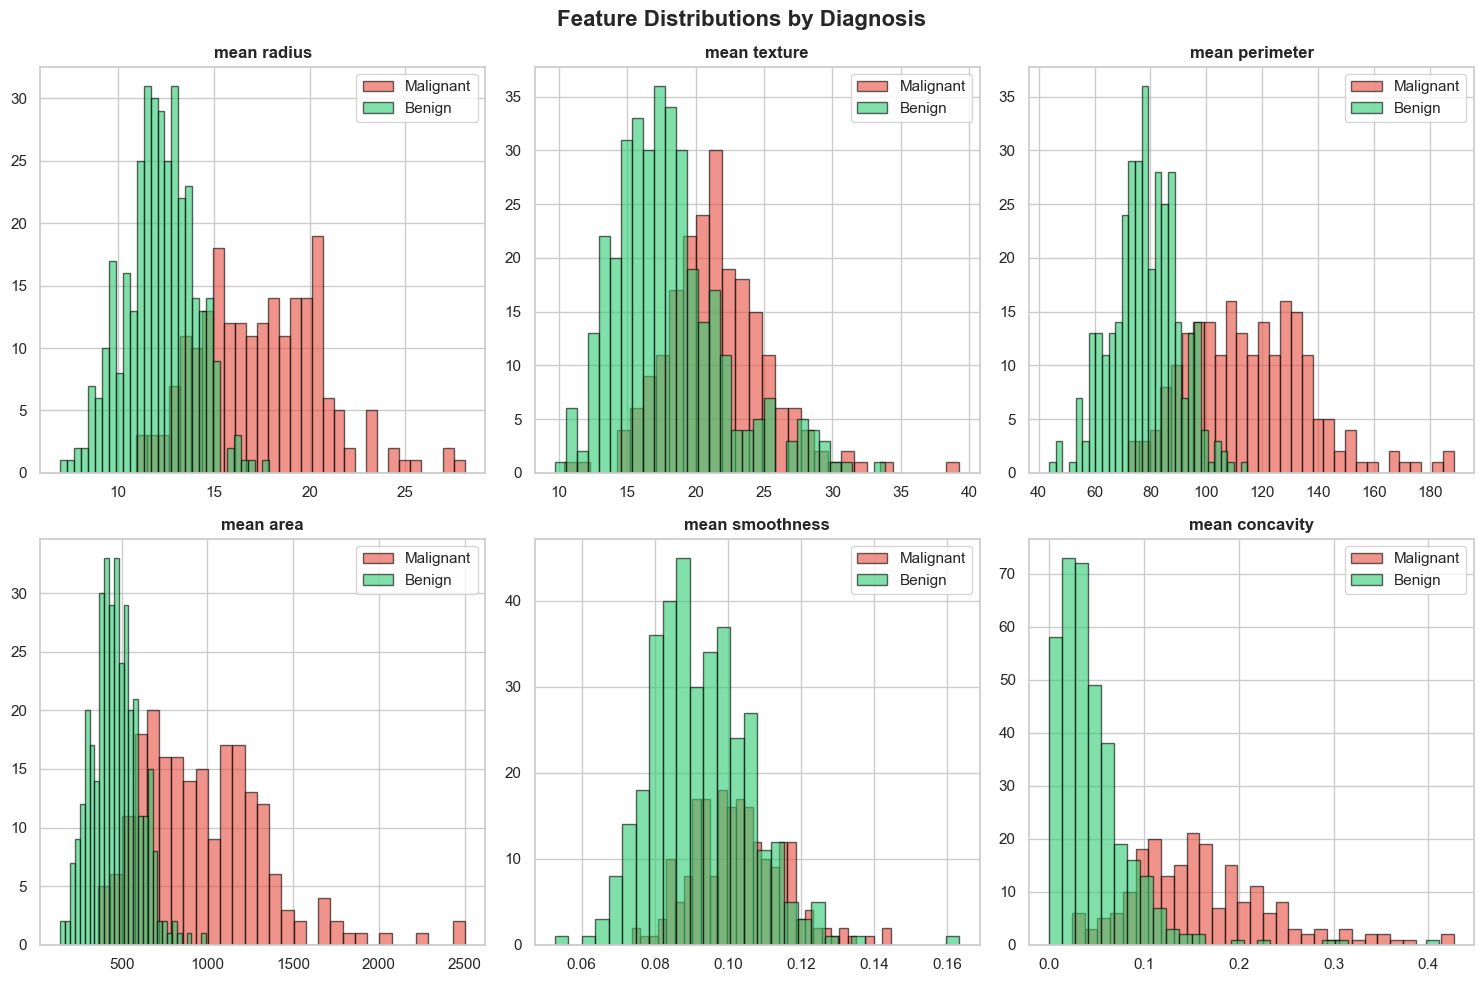

In [4]:
top_features = ['mean radius', 'mean texture',
                'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for diagnosis, color in zip(['Malignant','Benign'],['#e74c3c','#2ecc71']):
        subset = df[df['diagnosis']==diagnosis][feature]
        axes[i].hist(subset, bins=30, alpha=0.6,
                     color=color, label=diagnosis, edgecolor='black')
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].legend()

plt.suptitle('Feature Distributions by Diagnosis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

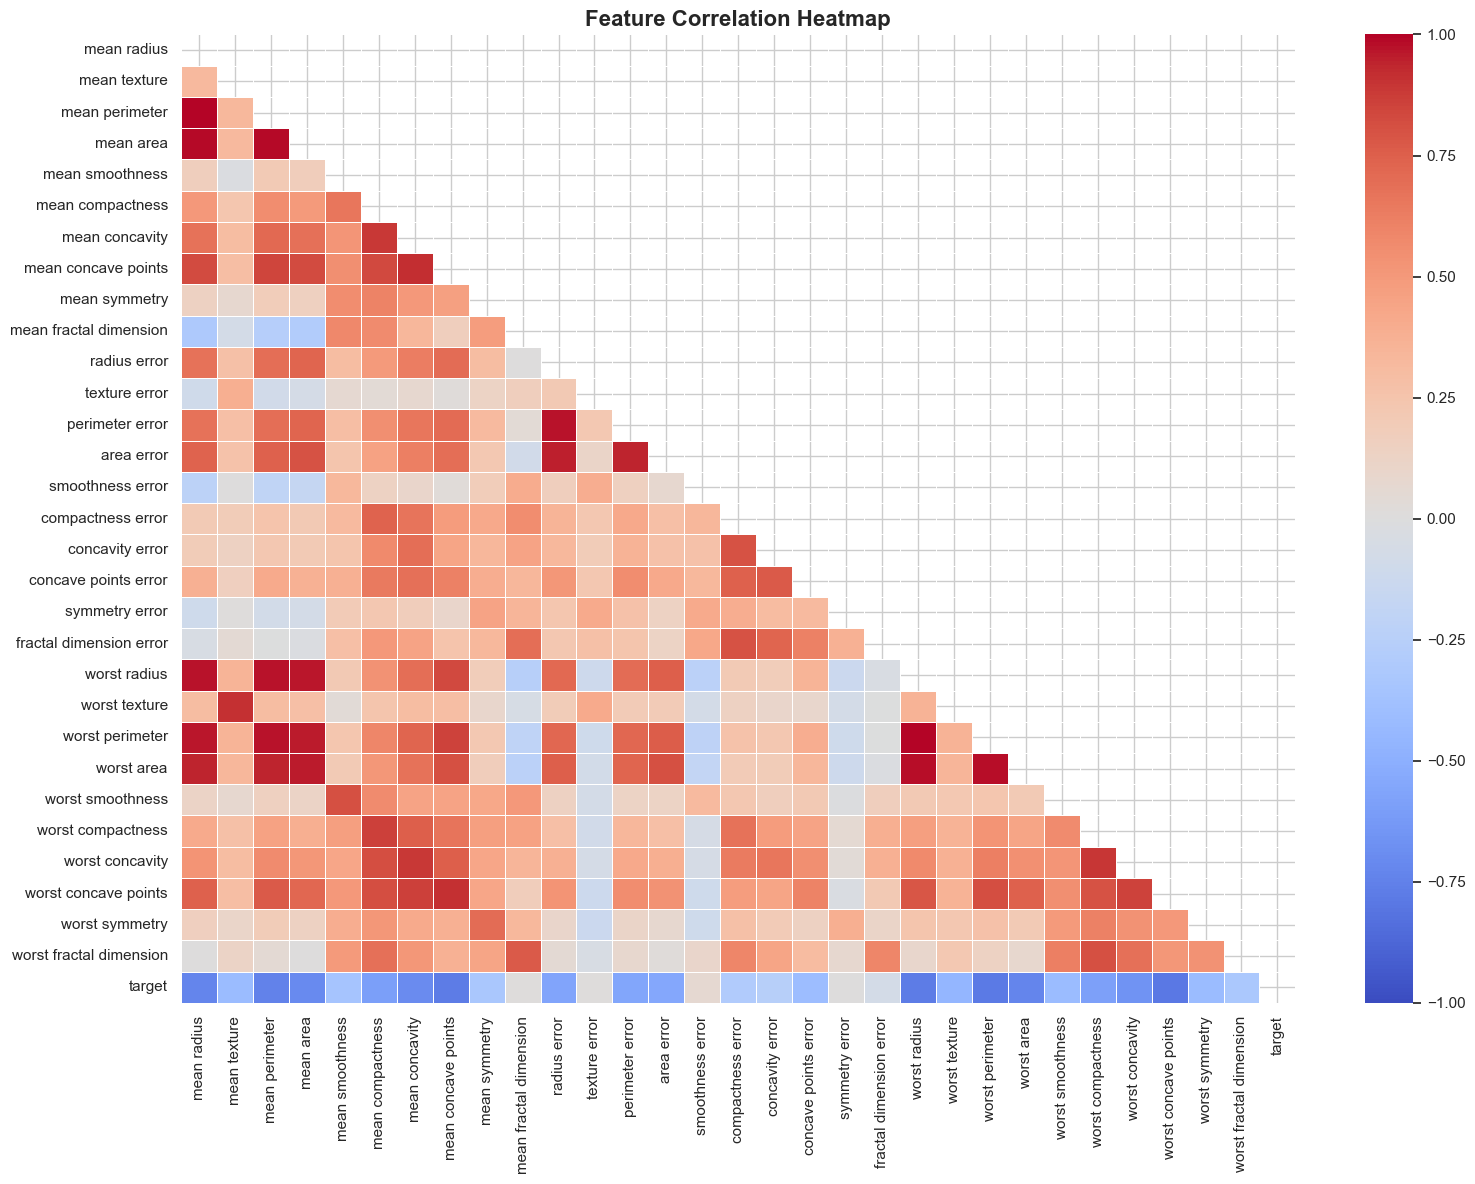

Top 10 features correlated with target:
target                  1.000000
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
Name: target, dtype: float64


In [5]:
plt.figure(figsize=(16, 12))
corr = df.drop(['diagnosis'], axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=False,
            cmap='coolwarm', linewidths=0.5,
            vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlated features with target
print("Top 10 features correlated with target:")
print(corr['target'].abs().sort_values(ascending=False).head(10))

C:\Users\TANMAY SHARMA\AppData\Local\Temp\ipykernel_6384\2455333326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df,
C:\Users\TANMAY SHARMA\AppData\Local\Temp\ipykernel_6384\2455333326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df,
C:\Users\TANMAY SHARMA\AppData\Local\Temp\ipykernel_6384\2455333326.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df,
C:\Users\TANMAY SHARMA\AppData\Local\Temp\ipykernel_6384\2455333326.py:6: FutureWa

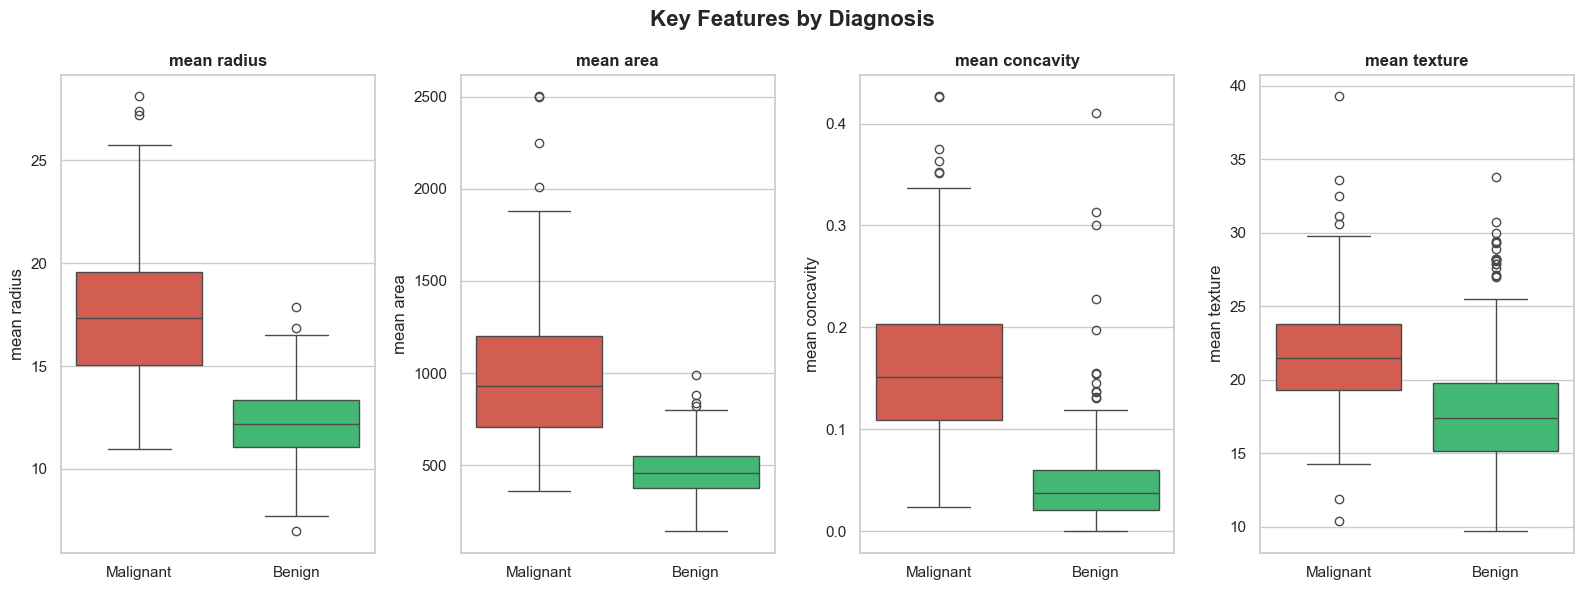

In [6]:
top4 = ['mean radius', 'mean area',
        'mean concavity', 'mean texture']

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
for i, feature in enumerate(top4):
    sns.boxplot(x='diagnosis', y=feature, data=df,
                palette={'Malignant':'#e74c3c','Benign':'#2ecc71'},
                ax=axes[i])
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Key Features by Diagnosis',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
print("""
KEY FINDINGS FROM EDA:
======================
1. Dataset has 569 samples — 212 Malignant, 357 Benign (no major imbalance)
2. No missing values found — clean dataset
3. Malignant tumors have HIGHER mean radius, area, perimeter
4. Mean concavity strongly separates Malignant vs Benign
5. Many features are highly correlated (multicollinearity present)
6. Random Forest is ideal here — handles correlated features well
7. Target variable is slightly imbalanced (37% vs 63%) — used stratify in split
""")


KEY FINDINGS FROM EDA:
1. Dataset has 569 samples — 212 Malignant, 357 Benign (no major imbalance)
2. No missing values found — clean dataset
3. Malignant tumors have HIGHER mean radius, area, perimeter
4. Mean concavity strongly separates Malignant vs Benign
5. Many features are highly correlated (multicollinearity present)
6. Random Forest is ideal here — handles correlated features well
7. Target variable is slightly imbalanced (37% vs 63%) — used stratify in split

